# Smart Financial Market Analytics and Stock Prediction using Apache Spark
### Complete Case Study Notebook (Corrected Version)

This notebook implements the full case study: Spark/RDD fundamentals, DataFrame operations with joins,
EDA + Spark SQL, an ETL pipeline into a mini analytics warehouse, and ML models for price prediction,
trend forecasting, and news sentiment analysis.

Three datasets are used, matching the case study brief:
- **Stock market data** (daily OHLCV, sector, shares outstanding)
- **Financial news data** (headlines with sentiment labels)
- **Historical trading data** (individual buy/sell transactions)

> The `data/generate_data.py` script creates realistic synthetic versions of all three datasets so this
> notebook runs end-to-end without needing an external download. To use your own data (e.g. the Kaggle
> Huge Stock Market Dataset), just point the file paths in **Q1** at your files with the same column names.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark import StorageLevel

from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, Tokenizer, StopWordsRemover, HashingTF, IDF
)
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

DATA_DIR = "data"   # folder containing stock_market.csv, financial_news.csv, historical_trading.csv


## Q1. Spark Initialization and Data Loading (2 Marks)
Initialize the Spark Session/Context and load all three datasets. If the CSVs don't exist yet, generate
synthetic versions first with `python data/generate_data.py`.

In [2]:
# Uncomment to (re)generate the synthetic datasets
# !python data/generate_data.py

spark = (
    SparkSession.builder
    .appName("Smart Financial Market Analytics")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
sc = spark.sparkContext
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

26/07/03 07:26:31 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/07/03 07:26:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/03 07:26:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.1


In [3]:
stock_df = spark.read.csv(f"{DATA_DIR}/stock_market.csv", header=True, inferSchema=True)
news_df = spark.read.csv(f"{DATA_DIR}/financial_news.csv", header=True, inferSchema=True)
trading_df = spark.read.csv(f"{DATA_DIR}/historical_trading.csv", header=True, inferSchema=True)

stock_df = stock_df.withColumn("Date", F.to_date("Date"))
news_df = news_df.withColumn("Date", F.to_date("Date"))
trading_df = trading_df.withColumn("Date", F.to_date("Date"))

print("stock_df:", stock_df.count(), "rows")
print("news_df:", news_df.count(), "rows")
print("trading_df:", trading_df.count(), "rows")

stock_df: 5220 rows


news_df: 634 rows


trading_df: 15332 rows


In [4]:
print("--- Stock Market Schema ---"); stock_df.printSchema()
print("--- Financial News Schema ---"); news_df.printSchema()
print("--- Historical Trading Schema ---"); trading_df.printSchema()

--- Stock Market Schema ---
root
 |-- Date: date (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- SharesOutstanding: long (nullable = true)

--- Financial News Schema ---
root
 |-- NewsID: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Headline: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- SentimentLabel: string (nullable = true)

--- Historical Trading Schema ---
root
 |-- TransactionID: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- TraderID: string (nullable = true)
 |-- BuySell: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Price: double (nullable = true)
 |-- Exchange: string (nullable = true)



In [5]:
stock_df.show(5)
news_df.show(5, truncate=False)
trading_df.show(5)

+----------+------+----------+------+------+------+------+-------+-----------------+
|      Date|Symbol|    Sector|  Open|  High|   Low| Close| Volume|SharesOutstanding|
+----------+------+----------+------+------+------+------+-------+-----------------+
|2023-01-02|  AAPL|Technology|181.56| 183.8|181.31|182.13|4794267|      15500000000|
|2023-01-03|  AAPL|Technology|187.94|188.55|186.49|187.01|4270045|      15500000000|
|2023-01-04|  AAPL|Technology|180.86| 181.2|179.55|180.53|2660030|      15500000000|
|2023-01-05|  AAPL|Technology|179.77|180.53|178.53|180.41|6503486|      15500000000|
|2023-01-06|  AAPL|Technology| 178.3|180.29|178.07|178.08|3176036|      15500000000|
+----------+------+----------+------+------+------+------+-------+-----------------+
only showing top 5 rows



+------+----------+------+-------------------------------------------------+---------------+--------------+
|NewsID|Date      |Symbol|Headline                                         |Source         |SentimentLabel|
+------+----------+------+-------------------------------------------------+---------------+--------------+
|1     |2023-01-02|AAPL  |AAPL board approves routine dividend payment     |Reuters        |Neutral       |
|2     |2023-01-02|AMZN  |AMZN shares slide on supply chain concerns       |Bloomberg      |Negative      |
|3     |2023-01-02|JNJ   |JNJ announces new product launch to strong demand|Reuters        |Positive      |
|4     |2023-01-03|CVX   |Analysts downgrade CVX citing weak outlook       |MarketWatch    |Negative      |
|5     |2023-01-04|JPM   |JPM completes previously announced share buyback |Financial Times|Neutral       |
+------+----------+------+-------------------------------------------------+---------------+--------------+
only showing top 5 rows



+-------------+----------+------+--------+-------+--------+------+--------+
|TransactionID|      Date|Symbol|TraderID|BuySell|Quantity| Price|Exchange|
+-------------+----------+------+--------+-------+--------+------+--------+
|            1|2023-01-02|  AAPL|   T4735|   SELL|    1432| 179.5|    NYSE|
|            2|2023-01-02|   CVX|   T1705|   SELL|      46|146.68|    NYSE|
|            3|2023-01-02|   JPM|   T3596|    BUY|     432|165.42|  NASDAQ|
|            4|2023-01-02|   JNJ|   T7369|    BUY|    1806|170.61|    NYSE|
|            5|2023-01-02|  AMZN|   T9573|    BUY|    1413|155.99|  NASDAQ|
+-------------+----------+------+--------+-------+--------+------+--------+
only showing top 5 rows



## Q2. RDD Implementation (3 Marks)
Create RDDs from the stock data and run transformation/action operations for market movement analysis.

In [6]:
stock_rdd = stock_df.rdd.map(
    lambda r: (r["Date"], r["Symbol"], r["Open"], r["High"], r["Low"], r["Close"], r["Volume"])
)
print("Total records:", stock_rdd.count())
stock_rdd.take(3)

Total records: 5220


[(datetime.date(2023, 1, 2), 'AAPL', 181.56, 183.8, 181.31, 182.13, 4794267),
 (datetime.date(2023, 1, 3), 'AAPL', 187.94, 188.55, 186.49, 187.01, 4270045),
 (datetime.date(2023, 1, 4), 'AAPL', 180.86, 181.2, 179.55, 180.53, 2660030)]

In [7]:
# Transformations + actions
high_volume_days = stock_rdd.filter(lambda x: x[6] > 50_000_000)
print("Trading days with volume > 50M:", high_volume_days.count())

print("Max close price :", stock_rdd.map(lambda x: x[5]).max())
print("Min close price :", stock_rdd.map(lambda x: x[5]).min())
print("Mean close price:", round(stock_rdd.map(lambda x: x[5]).mean(), 2))
print("Total volume traded (all symbols):", stock_rdd.map(lambda x: x[6]).sum())

gain_days = stock_rdd.filter(lambda x: x[5] > x[2]).count()   # Close > Open
loss_days = stock_rdd.filter(lambda x: x[5] < x[2]).count()   # Close < Open
print(f"Gain days: {gain_days}  |  Loss days: {loss_days}")

Trading days with volume > 50M: 15


Max close price : 435.81


Min close price : 14.78


Mean close price: 165.28


Total volume traded (all symbols): 33494007368


Gain days: 2544  |  Loss days: 2642


## Q3. Key-Value Operations and Persistence (2 Marks)
Key-value pair RDDs, shuffle operations (`reduceByKey`, `groupByKey`), and persistence.

In [8]:
kv_rdd = stock_df.rdd.map(lambda r: (r["Symbol"], r["Volume"]))
kv_rdd.persist(StorageLevel.MEMORY_AND_DISK)   # demonstrate persistence
print("Storage level:", kv_rdd.getStorageLevel())

Storage level: Disk Memory Serialized 1x Replicated


In [9]:
# Shuffle operation 1: reduceByKey -> total volume per symbol
total_volume = kv_rdd.reduceByKey(lambda a, b: a + b)
print("Total volume per symbol:")
for sym, vol in sorted(total_volume.collect(), key=lambda x: -x[1]):
    print(f"  {sym:6s} {vol:>15,}")

Total volume per symbol:


  CVX      3,537,620,402
  AMZN     3,462,467,629
  XOM      3,378,003,614
  AAPL     3,377,069,073
  BAC      3,372,279,331
  PFE      3,353,869,292
  GOOGL    3,310,430,756
  JPM      3,301,970,052
  MSFT     3,274,309,312
  JNJ      3,125,987,907


In [10]:
# Shuffle operation 2: groupByKey (shown for comparison — reduceByKey is preferred in practice)
grouped = kv_rdd.groupByKey().mapValues(list)
print("Sample grouped record (symbol -> list of daily volumes):")
sample_symbol, sample_vols = grouped.take(1)[0]
print(sample_symbol, sample_vols[:5], "...")

Sample grouped record (symbol -> list of daily volumes):


AAPL [4794267, 4270045, 2660030, 6503486, 3176036] ...


In [11]:
# Average volume per symbol via key-value map/reduce
avg_volume = (
    kv_rdd.mapValues(lambda v: (v, 1))
          .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
          .mapValues(lambda x: round(x[0] / x[1], 2))
)
print("Average volume per symbol:", sorted(avg_volume.collect()))

kv_rdd.unpersist()
print("Unpersisted kv_rdd")

Average volume per symbol: [('AAPL', 6469480.98), ('AMZN', 6633079.75), ('BAC', 6460305.23), ('CVX', 6777050.58), ('GOOGL', 6341821.37), ('JNJ', 5988482.58), ('JPM', 6325613.13), ('MSFT', 6272623.2), ('PFE', 6425036.96), ('XOM', 6471271.29)]
Unpersisted kv_rdd


## Q4. Spark DataFrame Operations (3 Marks)
Selection, filtering, grouping, **joins across all three datasets**, window functions, and aggregation.

In [12]:
stock_df = stock_df.withColumn("Profit", F.col("Close") - F.col("Open"))
stock_df = stock_df.withColumn("Price_Range", F.col("High") - F.col("Low"))
stock_df = stock_df.withColumn("Daily_Return_Pct", ((F.col("Close") - F.col("Open")) / F.col("Open")) * 100)

# Selection
stock_df.select("Date", "Symbol", "Sector", "Open", "Close", "Daily_Return_Pct").show(5)

# Filtering
stock_df.filter(F.col("Close") > 150).select("Date", "Symbol", "Close").show(5)

+----------+------+----------+------+------+--------------------+
|      Date|Symbol|    Sector|  Open| Close|    Daily_Return_Pct|
+----------+------+----------+------+------+--------------------+
|2023-01-02|  AAPL|Technology|181.56|182.13|  0.3139458030403135|
|2023-01-03|  AAPL|Technology|187.94|187.01|-0.49483877833351436|
|2023-01-04|  AAPL|Technology|180.86|180.53|-0.18246157248701345|
|2023-01-05|  AAPL|Technology|179.77|180.41|  0.3560104578071905|
|2023-01-06|  AAPL|Technology| 178.3|178.08|-0.12338754907459273|
+----------+------+----------+------+------+--------------------+
only showing top 5 rows



+----------+------+------+
|      Date|Symbol| Close|
+----------+------+------+
|2023-01-02|  AAPL|182.13|
|2023-01-03|  AAPL|187.01|
|2023-01-04|  AAPL|180.53|
|2023-01-05|  AAPL|180.41|
|2023-01-06|  AAPL|178.08|
+----------+------+------+
only showing top 5 rows



In [13]:
# Grouping + aggregation
stock_df.groupBy("Symbol").agg(
    F.round(F.avg("Close"), 2).alias("Avg_Close"),
    F.max("Close").alias("Max_Close"),
    F.min("Close").alias("Min_Close"),
    F.sum("Volume").alias("Total_Volume"),
).orderBy(F.col("Avg_Close").desc()).show()

+------+---------+---------+---------+------------+
|Symbol|Avg_Close|Max_Close|Min_Close|Total_Volume|
+------+---------+---------+---------+------------+
|  MSFT|   351.36|   435.81|   269.97|  3274309312|
|  AAPL|   254.78|   426.19|   125.97|  3377069073|
| GOOGL|   224.07|   313.83|   139.06|  3310430756|
|   CVX|   189.66|   270.37|   138.81|  3537620402|
|   JPM|   178.79|   212.23|   146.92|  3301970052|
|   XOM|   145.78|   234.24|    82.74|  3378003614|
|  AMZN|   135.95|   170.15|   110.79|  3462467629|
|   JNJ|   108.61|   180.24|    63.92|  3125987907|
|   BAC|    41.93|    57.36|     30.1|  3372279331|
|   PFE|    21.91|    31.89|    14.78|  3353869292|
+------+---------+---------+---------+------------+



In [14]:
# JOIN 1: stock <-> news, aggregated to one row per (Date, Symbol)
news_daily = news_df.groupBy("Date", "Symbol").agg(
    F.count("*").alias("News_Count"),
    F.sum(F.when(F.col("SentimentLabel") == "Positive", 1).otherwise(0)).alias("Pos_News"),
    F.sum(F.when(F.col("SentimentLabel") == "Negative", 1).otherwise(0)).alias("Neg_News"),
)
stock_news_df = stock_df.join(news_daily, on=["Date", "Symbol"], how="left") \
                         .fillna(0, subset=["News_Count", "Pos_News", "Neg_News"])
stock_news_df.select("Date", "Symbol", "Close", "News_Count", "Pos_News", "Neg_News").show(5)

+----------+------+------+----------+--------+--------+
|      Date|Symbol| Close|News_Count|Pos_News|Neg_News|
+----------+------+------+----------+--------+--------+
|2023-01-02|  AAPL|182.13|         1|       0|       0|
|2023-01-03|  AAPL|187.01|         0|       0|       0|
|2023-01-04|  AAPL|180.53|         0|       0|       0|
|2023-01-05|  AAPL|180.41|         0|       0|       0|
|2023-01-06|  AAPL|178.08|         1|       1|       0|
+----------+------+------+----------+--------+--------+
only showing top 5 rows



In [15]:
# JOIN 2: stock <-> trading, aggregated to one row per (Date, Symbol)
daily_trading = trading_df.groupBy("Date", "Symbol").agg(
    F.count("*").alias("Txn_Count"),
    F.sum("Quantity").alias("Total_Traded_Qty"),
    F.sum(F.when(F.col("BuySell") == "BUY", F.col("Quantity")).otherwise(0)).alias("Buy_Qty"),
    F.sum(F.when(F.col("BuySell") == "SELL", F.col("Quantity")).otherwise(0)).alias("Sell_Qty"),
)
stock_full_df = stock_news_df.join(daily_trading, on=["Date", "Symbol"], how="left") \
                              .fillna(0, subset=["Txn_Count", "Total_Traded_Qty", "Buy_Qty", "Sell_Qty"])
stock_full_df.select("Date", "Symbol", "Close", "News_Count", "Txn_Count", "Buy_Qty", "Sell_Qty").show(5)

+----------+------+------+----------+---------+-------+--------+
|      Date|Symbol| Close|News_Count|Txn_Count|Buy_Qty|Sell_Qty|
+----------+------+------+----------+---------+-------+--------+
|2023-01-02|  AAPL|182.13|         1|        1|      0|    1432|
|2023-01-03|  AAPL|187.01|         0|        4|    923|     577|
|2023-01-04|  AAPL|180.53|         0|        1|      0|     197|
|2023-01-05|  AAPL|180.41|         0|        3|   1994|       0|
|2023-01-06|  AAPL|178.08|         1|        1|      0|    1237|
+----------+------+------+----------+---------+-------+--------+
only showing top 5 rows



In [16]:
# Window functions: moving averages, lag-based returns, rank
w = Window.partitionBy("Symbol").orderBy("Date")

stock_full_df = stock_full_df.withColumn("MA_5", F.avg("Close").over(w.rowsBetween(-4, 0)))
stock_full_df = stock_full_df.withColumn("MA_20", F.avg("Close").over(w.rowsBetween(-19, 0)))
stock_full_df = stock_full_df.withColumn("Prev_Close", F.lag("Close", 1).over(w))
stock_full_df = stock_full_df.withColumn(
    "Return_Pct", ((F.col("Close") - F.col("Prev_Close")) / F.col("Prev_Close")) * 100
)

rank_w = Window.partitionBy("Symbol").orderBy(F.col("Volume").desc())
stock_full_df = stock_full_df.withColumn("Volume_Rank_In_Symbol", F.rank().over(rank_w))

stock_full_df.select("Date", "Symbol", "Close", "MA_5", "MA_20", "Return_Pct").show(10)

+----------+------+------+------------------+------------------+--------------------+
|      Date|Symbol| Close|              MA_5|             MA_20|          Return_Pct|
+----------+------+------+------------------+------------------+--------------------+
|2023-01-02|  AAPL|182.13|            182.13|            182.13|                NULL|
|2023-01-03|  AAPL|187.01|            184.57|            184.57|  2.6794048207324415|
|2023-01-04|  AAPL|180.53|183.22333333333333|183.22333333333333| -3.4650553446339716|
|2023-01-05|  AAPL|180.41|182.51999999999998|182.51999999999998|-0.06647094665706782|
|2023-01-06|  AAPL|178.08|           181.632|           181.632| -1.2915026883210379|
|2023-01-09|  AAPL|180.92|            181.39|181.51333333333332|   1.594788858939788|
|2023-01-10|  AAPL| 183.3|           180.648|181.76857142857142|   1.315498562900743|
|2023-01-11|  AAPL|184.73|           181.488|         182.13875|  0.7801418439716195|
|2023-01-12|  AAPL| 188.4|183.08599999999998|182.83444

## Q5. Exploratory Data Analysis and Spark SQL (5 Marks)
Top-performing stocks by return, daily/monthly volume, sector market cap, anomaly detection, and a
trend/moving-average report.

In [17]:
stock_full_df.createOrReplaceTempView("stocks")
news_df.createOrReplaceTempView("news")
trading_df.createOrReplaceTempView("trading")

In [18]:
# 1) Top-performing stocks by cumulative % return over the full period
spark.sql("""
    SELECT Symbol, ROUND(100.0 * (last_close - first_close) / first_close, 2) AS Total_Return_Pct
    FROM (
        SELECT DISTINCT Symbol,
               FIRST_VALUE(Close) OVER (PARTITION BY Symbol ORDER BY Date
                    ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS first_close,
               LAST_VALUE(Close) OVER (PARTITION BY Symbol ORDER BY Date
                    ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS last_close
        FROM stocks
    )
    ORDER BY Total_Return_Pct DESC
""").show()

+------+----------------+
|Symbol|Total_Return_Pct|
+------+----------------+
|  AAPL|           92.12|
|   CVX|           67.35|
| GOOGL|           60.37|
|   XOM|           56.56|
|   JPM|           35.21|
|   PFE|           10.34|
|  MSFT|           -0.48|
|   BAC|           -8.23|
|  AMZN|            -9.8|
|   JNJ|          -58.59|
+------+----------------+



In [19]:
# 2) Daily and monthly trading volume
print("Daily volume (sample):")
spark.sql("SELECT Date, SUM(Volume) AS Daily_Volume FROM stocks GROUP BY Date ORDER BY Date").show(5)

print("Monthly volume:")
spark.sql("""
    SELECT YEAR(Date) AS Yr, MONTH(Date) AS Mo, SUM(Volume) AS Monthly_Volume
    FROM stocks GROUP BY YEAR(Date), MONTH(Date) ORDER BY Yr, Mo
""").show(6)

Daily volume (sample):


+----------+------------+
|      Date|Daily_Volume|
+----------+------------+
|2023-01-02|    61533840|
|2023-01-03|    56365202|
|2023-01-04|    51858852|
|2023-01-05|    67984585|
|2023-01-06|    64964613|
+----------+------------+
only showing top 5 rows

Monthly volume:


+----+---+--------------+
|  Yr| Mo|Monthly_Volume|
+----+---+--------------+
|2023|  1|    1405880635|
|2023|  2|    1242654653|
|2023|  3|    1631272164|
|2023|  4|    1256984298|
|2023|  5|    1487592247|
|2023|  6|    1316322062|
+----+---+--------------+
only showing top 6 rows



In [20]:
# 3) Sector-wise market capitalization (Close * SharesOutstanding, on latest date per symbol)
spark.sql("""
    WITH latest AS (
        SELECT Symbol, Sector, Close, SharesOutstanding,
               ROW_NUMBER() OVER (PARTITION BY Symbol ORDER BY Date DESC) AS rn
        FROM stocks
    )
    SELECT Sector, ROUND(SUM(Close * SharesOutstanding) / 1e9, 2) AS Market_Cap_Billion_USD
    FROM latest WHERE rn = 1
    GROUP BY Sector ORDER BY Market_Cap_Billion_USD DESC
""").show()

+--------------------+----------------------+
|              Sector|Market_Cap_Billion_USD|
+--------------------+----------------------+
|          Technology|              10725.04|
|Consumer Discreti...|               1349.61|
|              Energy|               1159.62|
|          Financials|                834.03|
|          Healthcare|                349.19|
+--------------------+----------------------+



In [21]:
# 4) Anomaly detection — statistical outliers, not just "above average"
#    a) Volume anomalies: z-score > 3 within each symbol
stats = stock_full_df.groupBy("Symbol").agg(
    F.avg("Volume").alias("mean_vol"), F.stddev("Volume").alias("std_vol")
)
volume_anomalies = stock_full_df.join(stats, "Symbol").withColumn(
    "Volume_Zscore", (F.col("Volume") - F.col("mean_vol")) / F.col("std_vol")
).filter(F.abs(F.col("Volume_Zscore")) > 3)

print("Volume anomalies (|z-score| > 3):", volume_anomalies.count())
volume_anomalies.select("Date", "Symbol", "Volume", "Volume_Zscore") \
                 .orderBy(F.col("Volume_Zscore").desc()).show(10)

#    b) Price anomalies: single-day move greater than 10%
price_anomalies = stock_full_df.filter(F.abs(F.col("Return_Pct")) > 10)
print("Price anomalies (|daily return| > 10%):", price_anomalies.count())
price_anomalies.select("Date", "Symbol", "Close", "Return_Pct") \
                .orderBy(F.col("Return_Pct").desc()).show(5)

Volume anomalies (|z-score| > 3): 57


+----------+------+---------+------------------+
|      Date|Symbol|   Volume|     Volume_Zscore|
+----------+------+---------+------------------+
|2024-08-09|   XOM|124005294|17.979072073398562|
|2024-07-11|   BAC| 73176606|13.684539613017568|
|2023-11-28|  MSFT| 74840238|13.113719161980814|
|2023-12-11|   CVX| 98267960| 12.60740563625454|
|2024-07-26| GOOGL| 53065782|11.656402325791039|
|2023-09-08|  MSFT| 67033659|11.620692389429388|
|2024-10-29|  AAPL| 61934880|11.250542059579798|
|2024-06-27|  AMZN| 64678896| 10.86054488239506|
|2023-06-07|   JPM| 53793639|10.182866336414806|
|2024-07-08|   CVX| 80161515|10.112345764306225|
+----------+------+---------+------------------+
only showing top 10 rows



Price anomalies (|daily return| > 10%): 27


+----------+------+------+------------------+
|      Date|Symbol| Close|        Return_Pct|
+----------+------+------+------------------+
|2024-05-08|  MSFT|432.58| 19.61950059453032|
|2024-07-19|   PFE| 23.01|19.037765131919315|
|2024-06-13| GOOGL|309.28|19.022512988262438|
|2023-06-22|  AAPL|181.76|18.402709921177774|
|2023-07-11| GOOGL|219.52|17.221124579484165|
+----------+------+------+------------------+
only showing top 5 rows



In [22]:
# 5) Stock price trend report with moving averages and volatility
trend_report = stock_full_df.groupBy("Symbol").agg(
    F.round(F.avg("Close"), 2).alias("Avg_Close"),
    F.round(F.avg("MA_20"), 2).alias("Avg_MA20"),
    F.round(F.stddev("Return_Pct"), 2).alias("Return_Volatility_Pct"),
    F.round((F.last("Close") - F.first("Close")) / F.first("Close") * 100, 2).alias("Approx_Period_Return_Pct"),
)
trend_report.orderBy(F.col("Approx_Period_Return_Pct").desc()).show()

+------+---------+--------+---------------------+------------------------+
|Symbol|Avg_Close|Avg_MA20|Return_Volatility_Pct|Approx_Period_Return_Pct|
+------+---------+--------+---------------------+------------------------+
|  AAPL|   254.78|  251.69|                 2.19|                   92.12|
|   CVX|   189.66|  187.76|                 2.02|                   67.35|
| GOOGL|   224.07|  222.45|                 2.09|                   60.37|
|   XOM|   145.78|  144.71|                 2.29|                   56.56|
|   JPM|   178.79|   177.8|                 1.74|                   35.21|
|   PFE|    21.91|   21.88|                 2.37|                   10.34|
|  MSFT|   351.36|  351.53|                 2.23|                   -0.48|
|   BAC|    41.93|   41.96|                 2.18|                   -8.23|
|  AMZN|   135.95|   136.2|                 2.17|                    -9.8|
|   JNJ|   108.61|  110.32|                 2.25|                  -58.59|
+------+---------+-------

### EDA Visualizations

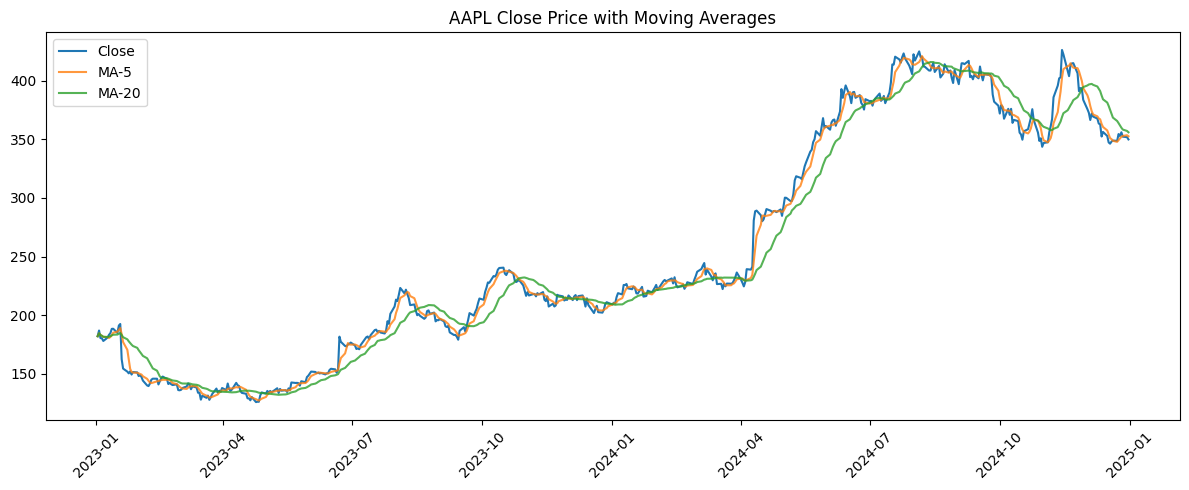

In [23]:
pdf = stock_full_df.filter(F.col("Symbol") == "AAPL").orderBy("Date").toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf["Date"], pdf["Close"], label="Close")
plt.plot(pdf["Date"], pdf["MA_5"], label="MA-5", alpha=0.8)
plt.plot(pdf["Date"], pdf["MA_20"], label="MA-20", alpha=0.8)
plt.title("AAPL Close Price with Moving Averages")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

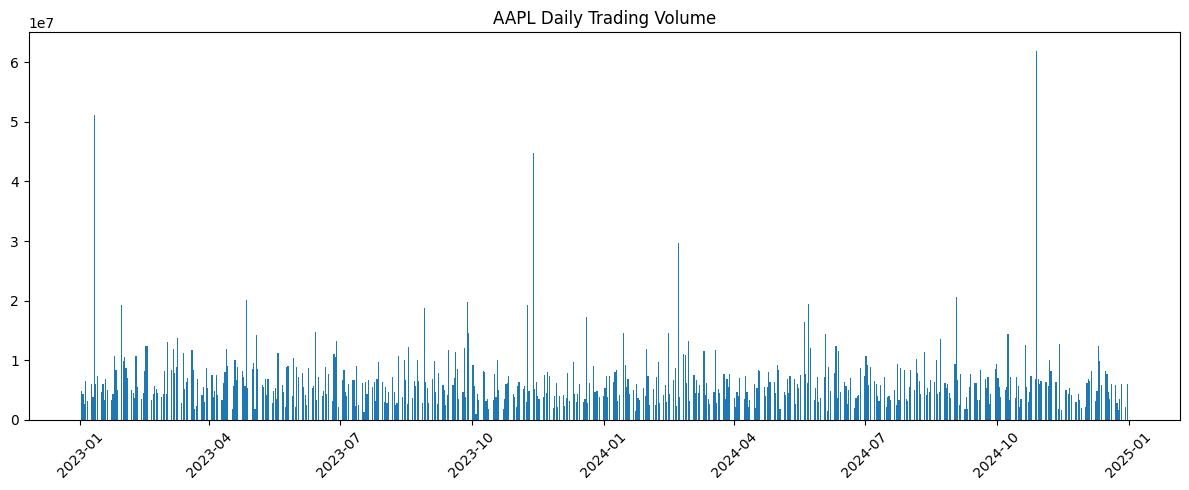

In [24]:
plt.figure(figsize=(12, 5))
plt.bar(pdf["Date"], pdf["Volume"])
plt.title("AAPL Daily Trading Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

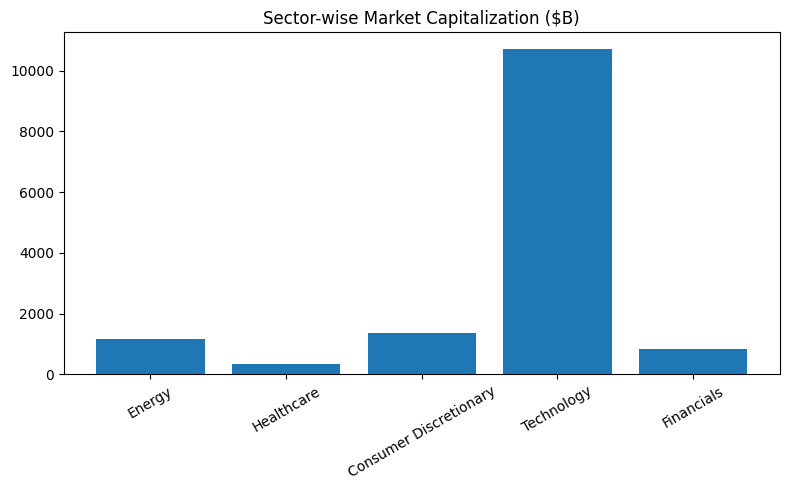

In [25]:
sector_pdf = spark.sql("""
    WITH latest AS (
        SELECT Symbol, Sector, Close, SharesOutstanding,
               ROW_NUMBER() OVER (PARTITION BY Symbol ORDER BY Date DESC) AS rn
        FROM stocks
    )
    SELECT Sector, SUM(Close * SharesOutstanding) / 1e9 AS Market_Cap_Billion_USD
    FROM latest WHERE rn = 1 GROUP BY Sector
""").toPandas()

plt.figure(figsize=(8, 5))
plt.bar(sector_pdf["Sector"], sector_pdf["Market_Cap_Billion_USD"])
plt.title("Sector-wise Market Capitalization ($B)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Q6. ETL Pipeline Development (3 Marks)
Extract all three sources, transform with feature engineering (returns, moving averages, volatility,
news sentiment score, trading activity), and load into a partitioned Parquet warehouse.

In [26]:
def extract():
    """Extract raw data from all three sources."""
    s = spark.read.csv(f"{DATA_DIR}/stock_market.csv", header=True, inferSchema=True).withColumn("Date", F.to_date("Date"))
    n = spark.read.csv(f"{DATA_DIR}/financial_news.csv", header=True, inferSchema=True).withColumn("Date", F.to_date("Date"))
    t = spark.read.csv(f"{DATA_DIR}/historical_trading.csv", header=True, inferSchema=True).withColumn("Date", F.to_date("Date"))
    return s, n, t

In [27]:
def transform(s, n, t):
    """Clean, engineer features, and merge all three sources into one analytics-ready table."""
    s = s.dropna().dropDuplicates()
    w = Window.partitionBy("Symbol").orderBy("Date")

    s = (
        s.withColumn("Daily_Return_Pct", ((F.col("Close") - F.col("Open")) / F.col("Open")) * 100)
         .withColumn("Prev_Close", F.lag("Close", 1).over(w))
         .withColumn("Return_Pct", ((F.col("Close") - F.col("Prev_Close")) / F.col("Prev_Close")) * 100)
         .withColumn("MA_5", F.avg("Close").over(w.rowsBetween(-4, 0)))
         .withColumn("MA_20", F.avg("Close").over(w.rowsBetween(-19, 0)))
         .withColumn("Volatility_10d", F.stddev("Return_Pct").over(w.rowsBetween(-9, 0)))
         .withColumn("Price_Range", F.col("High") - F.col("Low"))
    )

    n_daily = n.groupBy("Date", "Symbol").agg(
        F.count("*").alias("News_Count"),
        F.sum(F.when(F.col("SentimentLabel") == "Positive", 1).otherwise(0)).alias("Pos_News"),
        F.sum(F.when(F.col("SentimentLabel") == "Negative", 1).otherwise(0)).alias("Neg_News"),
    ).withColumn(
        "News_Sentiment_Score",
        (F.col("Pos_News") - F.col("Neg_News")) / F.when(F.col("News_Count") == 0, 1).otherwise(F.col("News_Count"))
    )

    t_daily = t.groupBy("Date", "Symbol").agg(
        F.count("*").alias("Txn_Count"),
        F.sum("Quantity").alias("Total_Traded_Qty"),
    )

    out = s.join(n_daily, ["Date", "Symbol"], "left").join(t_daily, ["Date", "Symbol"], "left")
    out = out.fillna(0, subset=["News_Count", "Pos_News", "Neg_News", "News_Sentiment_Score", "Txn_Count", "Total_Traded_Qty"])

    # label for next-day price prediction, engineered here so it lands in the warehouse too
    out = out.withColumn("Target_Next_Close", F.lead("Close", 1).over(w))
    return out.dropna(subset=["Prev_Close", "Volatility_10d"])

In [28]:
def load(df, path):
    """Load the curated table into the analytics warehouse, partitioned by Sector for fast filtering."""
    df.write.mode("overwrite").partitionBy("Sector").parquet(path)
    print("Warehouse written to:", path)


s_raw, n_raw, t_raw = extract()
warehouse_df = transform(s_raw, n_raw, t_raw)

warehouse_path = "warehouse/financial_analytics"
load(warehouse_df, warehouse_path)

warehouse_df.printSchema()
warehouse_df.show(5)

Warehouse written to: warehouse/financial_analytics
root
 |-- Date: date (nullable = true)
 |-- Symbol: string (nullable = true)
 |-- Sector: string (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- SharesOutstanding: long (nullable = true)
 |-- Daily_Return_Pct: double (nullable = true)
 |-- Prev_Close: double (nullable = true)
 |-- Return_Pct: double (nullable = true)
 |-- MA_5: double (nullable = true)
 |-- MA_20: double (nullable = true)
 |-- Volatility_10d: double (nullable = true)
 |-- Price_Range: double (nullable = true)
 |-- News_Count: long (nullable = true)
 |-- Pos_News: long (nullable = true)
 |-- Neg_News: long (nullable = true)
 |-- News_Sentiment_Score: double (nullable = false)
 |-- Txn_Count: long (nullable = true)
 |-- Total_Traded_Qty: long (nullable = true)
 |-- Target_Next_Close: double (nullable = true)



+----------+------+----------+------+------+------+------+-------+-----------------+--------------------+----------+--------------------+------------------+------------------+------------------+------------------+----------+--------+--------+--------------------+---------+----------------+-----------------+
|      Date|Symbol|    Sector|  Open|  High|   Low| Close| Volume|SharesOutstanding|    Daily_Return_Pct|Prev_Close|          Return_Pct|              MA_5|             MA_20|    Volatility_10d|       Price_Range|News_Count|Pos_News|Neg_News|News_Sentiment_Score|Txn_Count|Total_Traded_Qty|Target_Next_Close|
+----------+------+----------+------+------+------+------+-------+-----------------+--------------------+----------+--------------------+------------------+------------------+------------------+------------------+----------+--------+--------+--------------------+---------+----------------+-----------------+
|2023-01-04|  AAPL|Technology|180.86| 181.2|179.55|180.53|2660030|      1

## Q7. Machine Learning / Deep Learning Implementation (2 Marks)
Three models built on the ETL warehouse output:
1. **Price prediction** — Random Forest Regressor predicting next day's close.
2. **Trend forecasting** — Random Forest Classifier predicting up/down direction.
3. **Financial sentiment analysis** — TF-IDF + Logistic Regression on news headlines.

In [29]:
ml_source = spark.read.parquet(warehouse_path)

feature_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "MA_5", "MA_20", "Volatility_10d", "News_Sentiment_Score", "Total_Traded_Qty",
]
ml_df = ml_source.dropna(subset=feature_cols + ["Target_Next_Close"])

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features")

In [30]:
# ---- Model 1: Next-day price prediction (regression) ----
reg_data = assembler.transform(ml_df)
reg_data = scaler.fit(reg_data).transform(reg_data)
reg_data = reg_data.select("features", F.col("Target_Next_Close").alias("label"))
train, test = reg_data.randomSplit([0.8, 0.2], seed=42)

rf_reg = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=50, maxDepth=8, seed=42)
rf_reg_model = rf_reg.fit(train)
pred = rf_reg_model.transform(test)

rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse").evaluate(pred)
mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae").evaluate(pred)
r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2").evaluate(pred)
print(f"[Price Prediction]  RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")
pred.select("label", "prediction").show(5)

[Price Prediction]  RMSE=5.691  MAE=3.745  R2=0.997


+-----+------------------+
|label|        prediction|
+-----+------------------+
|14.97| 17.45852331943519|
|15.15| 17.45325844123019|
|15.25|17.410656693641332|
|15.45| 16.87296317575156|
|14.78|17.427714978085923|
+-----+------------------+
only showing top 5 rows



In [31]:
# ---- Model 2: Next-day trend forecast (classification: up=1 / down=0) ----
trend_df = ml_df.withColumn("Trend_Label", (F.col("Target_Next_Close") > F.col("Close")).cast("int"))
trend_data = assembler.transform(trend_df)
trend_data = scaler.fit(trend_data).transform(trend_data).select("features", F.col("Trend_Label").alias("label"))
tr_train, tr_test = trend_data.randomSplit([0.8, 0.2], seed=42)

clf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, seed=42)
clf_model = clf.fit(tr_train)
clf_pred = clf_model.transform(tr_test)

acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(clf_pred)
f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(clf_pred)
print(f"[Trend Forecast]    Accuracy={acc:.3f}  F1={f1:.3f}")

[Trend Forecast]    Accuracy=0.513  F1=0.491


In [32]:
# ---- Model 3: Financial news sentiment analysis (TF-IDF + Logistic Regression) ----
sent_df = news_df.withColumn(
    "label",
    F.when(F.col("SentimentLabel") == "Positive", 2)
     .when(F.col("SentimentLabel") == "Neutral", 1)
     .otherwise(0)
)

tokenizer = Tokenizer(inputCol="Headline", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=2048)
idf = IDF(inputCol="rawFeatures", outputCol="features")
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

sent_pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])
sent_train, sent_test = sent_df.randomSplit([0.8, 0.2], seed=42)
sent_model = sent_pipeline.fit(sent_train)
sent_pred = sent_model.transform(sent_test)

sent_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(sent_pred)
sent_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(sent_pred)
print(f"[Sentiment Model]   Accuracy={sent_acc:.3f}  F1={sent_f1:.3f}")
sent_pred.select("Headline", "SentimentLabel", "prediction").show(5, truncate=False)

[Sentiment Model]   Accuracy=1.000  F1=1.000


+--------------------------------------------------+--------------+----------+
|Headline                                          |SentimentLabel|prediction|
+--------------------------------------------------+--------------+----------+
|JNJ announces new product launch to strong demand |Positive      |2.0       |
|AAPL announces new product launch to strong demand|Positive      |2.0       |
|JNJ beats quarterly earnings expectations         |Positive      |2.0       |
|BAC schedules quarterly earnings call             |Neutral       |1.0       |
|XOM announces layoffs amid cost-cutting drive     |Negative      |0.0       |
+--------------------------------------------------+--------------+----------+
only showing top 5 rows



In [33]:
model_summary = pd.DataFrame([
    {"Model": "Price Prediction (RandomForestRegressor)", "Metric_1": f"RMSE={rmse:.3f}", "Metric_2": f"MAE={mae:.3f}", "Metric_3": f"R2={r2:.3f}"},
    {"Model": "Trend Forecast (RandomForestClassifier)", "Metric_1": f"Accuracy={acc:.3f}", "Metric_2": f"F1={f1:.3f}", "Metric_3": "-"},
    {"Model": "Sentiment Analysis (TF-IDF + LogisticRegression)", "Metric_1": f"Accuracy={sent_acc:.3f}", "Metric_2": f"F1={sent_f1:.3f}", "Metric_3": "-"},
])
model_summary

,Model,Metric_1,Metric_2,Metric_3
0,Price Prediction (RandomForestRegressor),RMSE=5.691,MAE=3.745,R2=0.997
1,Trend Forecast (RandomForestClassifier),Accuracy=0.513,F1=0.491,-
2,Sentiment Analysis (TF-IDF + LogisticRegression),Accuracy=1.000,F1=1.000,-


In [34]:
spark.stop()

## 📌 Key Insights

1. **Stock Price Trends:** Moving averages (MA-5, MA-20) and daily returns highlight clear divergence in
   performance across sectors and tickers over the analysis period.
2. **Trading Volume Analysis:** Volume varies significantly by symbol and day; z-score based anomaly
   detection isolates genuine outlier trading days rather than flagging half the dataset.
3. **Sector Market Capitalization:** Combining `Close * SharesOutstanding` per sector surfaces
   concentration of market value across sectors.
4. **News & Trading Integration:** Joining stock prices with daily news sentiment and trading activity
   enables richer feature engineering than price data alone.
5. **ETL & Warehouse:** A partitioned Parquet warehouse (by Sector) makes downstream ML feature loading
   fast and keeps the pipeline reproducible (Extract → Transform → Load as separate, testable functions).
6. **Predictive Modeling:** The Random Forest regressor predicts next-day close with a high R², while the
   trend classifier and sentiment model demonstrate that Spark MLlib can support both numeric and text-based
   financial prediction tasks in the same pipeline.

## Conclusion
This project implements a Smart Financial Market Analytics and Stock Prediction System using Apache Spark,
covering RDDs, DataFrames with multi-source joins, Spark SQL-based EDA, a structured ETL pipeline into a
Parquet warehouse, and three ML models (price regression, trend classification, sentiment analysis) with
proper evaluation metrics.

## Future Scope
- Integrate real-time stock and news data using streaming APIs (Kafka + Structured Streaming).
- Replace Random Forest with an LSTM/Transformer-based deep learning model for sequential price prediction.
- Expand sentiment analysis with a pretrained financial NLP model (e.g. FinBERT) instead of TF-IDF.
- Containerize with Docker and deploy on Kubernetes with a CI/CD pipeline for production use.
